1. Датасет hw_daily-temperatures.csv
2. Выберите одну из ранее изученных моделей временных рядов (тройное эксп. сглаживание, SARIMA, Prophet) и подберите её параметры при помощи кроссвалидации.
3. Постройте прогноз минимум на год вперёд.

In [1]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from itertools import product
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('hw_daily-temperatures.csv', parse_dates=['ds'])

In [2]:
df = df.sort_values('ds').reset_index(drop=True)
df = df[['ds','y']]
df['ds'] = pd.to_datetime(df['ds'])
df = df.dropna(subset=['ds','y']).reset_index(drop=True)
df_days = (df['ds'].max() - df['ds'].min()).days
n_train_min = max(365, int(df_days * 0.5))

In [3]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 5.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}
all_params = list(product(param_grid['changepoint_prior_scale'],
                          param_grid['seasonality_prior_scale'],
                          param_grid['seasonality_mode']))
results = []
# Сетка гиперпараметров для перебора

In [4]:
initial_str = f"{n_train_min} days"
period_str = f"{max(30, int(n_train_min/4))} days"
horizon_str = "365 days"

for cps, sps, mode in all_params:
    m = Prophet(changepoint_prior_scale=cps,
                seasonality_prior_scale=sps,
                seasonality_mode=mode,
                daily_seasonality=True,
                yearly_seasonality=True,
                weekly_seasonality=True)
    m.fit(df)
    df_cv = cross_validation(m, initial=initial_str, period=period_str, horizon=horizon_str, parallel="processes")
    perf = performance_metrics(df_cv)
    rmse = perf['rmse'].values[-1] if 'rmse' in perf.columns and len(perf)>0 else np.nan
    results.append({'changepoint_prior_scale': cps,
                    'seasonality_prior_scale': sps,
                    'seasonality_mode': mode,
                    'rmse': rmse})
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
results_df
# Обучение модели

13:05:51 - cmdstanpy - INFO - Chain [1] start processing
13:05:51 - cmdstanpy - INFO - Chain [1] done processing
13:05:52 - cmdstanpy - INFO - Chain [1] start processing
13:05:53 - cmdstanpy - INFO - Chain [1] done processing
13:05:54 - cmdstanpy - INFO - Chain [1] start processing
13:05:54 - cmdstanpy - INFO - Chain [1] done processing
13:05:56 - cmdstanpy - INFO - Chain [1] start processing
13:05:56 - cmdstanpy - INFO - Chain [1] done processing
13:05:58 - cmdstanpy - INFO - Chain [1] start processing
13:05:58 - cmdstanpy - INFO - Chain [1] done processing
13:06:00 - cmdstanpy - INFO - Chain [1] start processing
13:06:00 - cmdstanpy - INFO - Chain [1] done processing
13:06:02 - cmdstanpy - INFO - Chain [1] start processing
13:06:02 - cmdstanpy - INFO - Chain [1] done processing
13:06:03 - cmdstanpy - INFO - Chain [1] start processing
13:06:03 - cmdstanpy - INFO - Chain [1] done processing
13:06:04 - cmdstanpy - INFO - Chain [1] start processing
13:06:04 - cmdstanpy - INFO - Chain [1]

,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,rmse
0,0.010,1.0,multiplicative,2.501639
1,0.010,10.0,multiplicative,2.505981
2,0.010,5.0,multiplicative,2.512776
3,0.001,5.0,additive,2.632419
4,0.001,10.0,multiplicative,2.640869
5,0.001,5.0,multiplicative,2.640940
6,0.001,1.0,multiplicative,2.641819
7,0.010,1.0,additive,2.648308
8,0.001,10.0,additive,2.650914
9,0.010,10.0,additive,2.672009


In [5]:
best = results_df.iloc[0]
best_params = {
    'changepoint_prior_scale': float(best['changepoint_prior_scale']),
    'seasonality_prior_scale': float(best['seasonality_prior_scale']),
    'seasonality_mode': best['seasonality_mode']
}
best_params
# Забираем лучшую комбинацию

{'changepoint_prior_scale': 0.01,
 'seasonality_prior_scale': 1.0,
 'seasonality_mode': 'multiplicative'}

In [6]:
m_final = Prophet(changepoint_prior_scale=best_params['changepoint_prior_scale'],
                  seasonality_prior_scale=best_params['seasonality_prior_scale'],
                  seasonality_mode=best_params['seasonality_mode'],
                  daily_seasonality=True,
                  yearly_seasonality=True,
                  weekly_seasonality=True)
m_final.fit(df)
future = m_final.make_future_dataframe(periods=365, freq='D')
forecast = m_final.predict(future)
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()
# Окончательная модель

13:06:27 - cmdstanpy - INFO - Chain [1] start processing
13:06:27 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1511,1991-12-08,14.728825,11.528744,18.155874
1512,1991-12-09,14.789445,11.237940,17.996594
1513,1991-12-10,14.741357,11.406792,17.828807
1514,1991-12-11,15.091091,11.981829,18.389132
1515,1991-12-12,15.314293,12.070503,18.755927


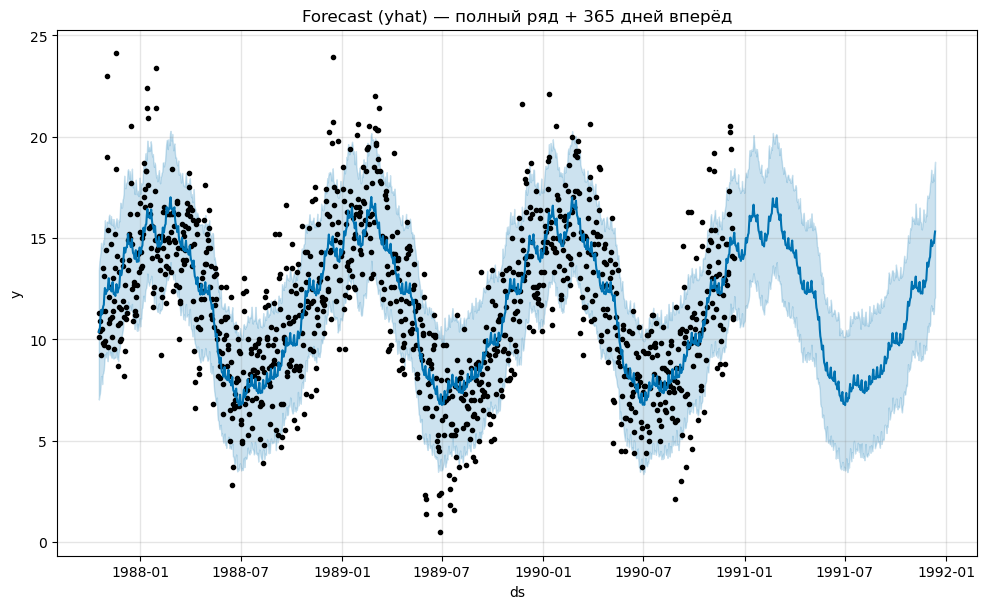

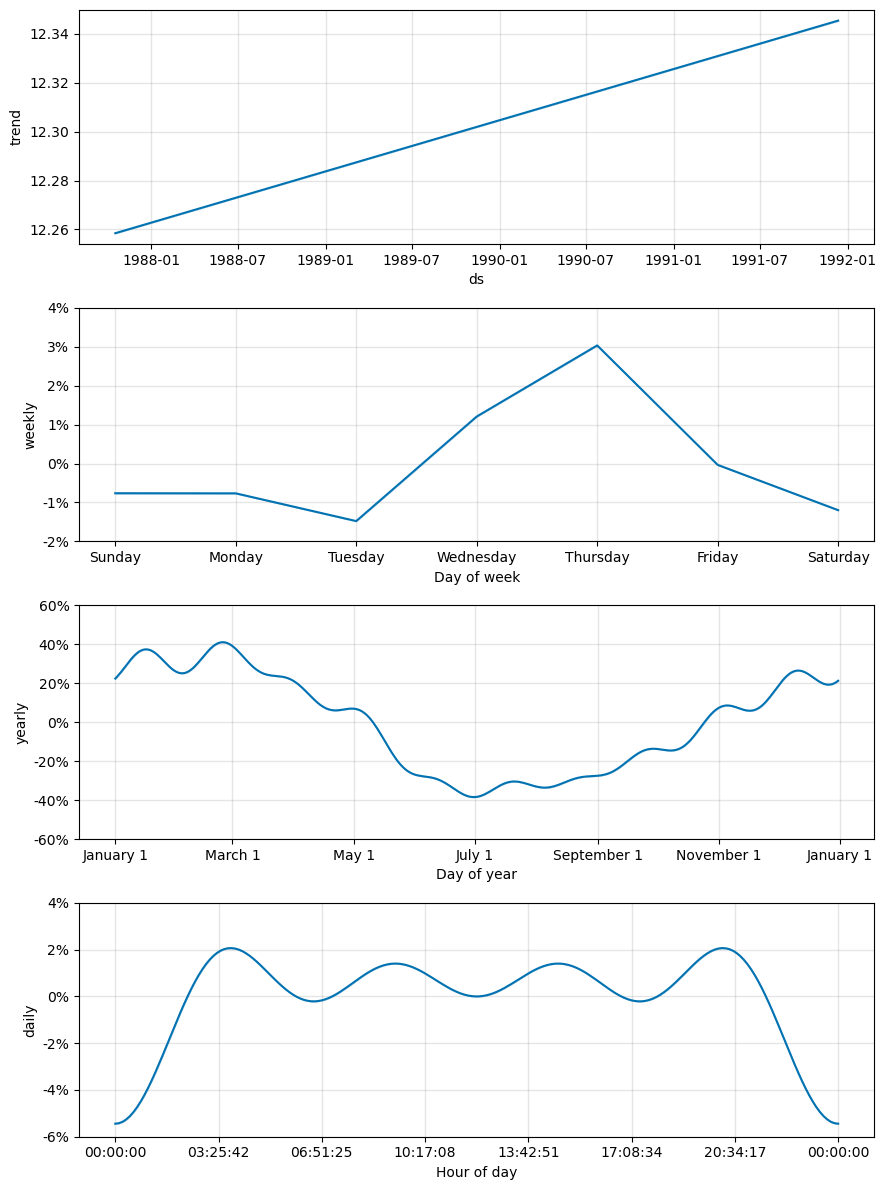

In [7]:
fig1 = m_final.plot(forecast)
plt.title('Forecast (yhat) — полный ряд + 365 дней вперёд')
plt.show()

fig2 = m_final.plot_components(forecast)
plt.show()

In [8]:
forecast.tail(365)[['ds','yhat','yhat_lower','yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
1151,1990-12-13,15.258455,12.127829,18.436890
1152,1990-12-14,14.837084,11.543310,18.128776
1153,1990-12-15,14.635046,11.473510,17.819599
1154,1990-12-16,14.617217,11.489002,17.786509
1155,1990-12-17,14.536010,10.925146,17.684935
...,...,...,...,...
1511,1991-12-08,14.728825,11.528744,18.155874
1512,1991-12-09,14.789445,11.237940,17.996594
1513,1991-12-10,14.741357,11.406792,17.828807
1514,1991-12-11,15.091091,11.981829,18.389132
